# LunarLanderContinuous Random Baseline

## 实验目标

这个 notebook 不训练任何策略，只统计 `LunarLanderContinuous-v3` 在随机连续动作下的表现。目标是先建立一个清晰基线：在需要连续控制主发动机和侧向发动机、同时兼顾姿态、速度和落点的任务里，随机动作通常只会带来失控和坠毁。后续 `SAC` 的结果会以这份 baseline 作为参照。

## 方法说明

方法就是纯随机动作采样：每一步直接从连续动作空间中随机取两个推力，不维护价值函数，也不更新策略。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "LunarLanderContinuous-v3"
NUM_EPISODES = 300
MAX_STEPS = 1000
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
SUCCESS_THRESHOLD_RETURN = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)

In [3]:
episode_returns = []
episode_lengths = []
successes = []
final_x = []
final_y = []
mean_abs_actions = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    actions = []
    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        actions.append(float(np.mean(np.abs(action))))
        if terminated or truncated:
            episode_lengths.append(step + 1)
            break
    episode_returns.append(total_reward)
    successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
    final_x.append(float(obs[0]))
    final_y.append(float(obs[1]))
    mean_abs_actions.append(float(np.mean(actions)))

env.close()

Random episodes:   0%|          | 0/300 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame({"reward": episode_returns, "episode_length": episode_lengths, "success": successes, "final_x": final_x, "final_y": final_y, "mean_abs_action": mean_abs_actions})
metrics = pd.DataFrame({"metric": ["average_reward", "success_rate", "average_episode_length", "average_final_x", "average_final_y", "average_mean_abs_action"], "value": [float(np.mean(episode_returns)), float(np.mean(successes)), float(np.mean(episode_lengths)), float(np.mean(final_x)), float(np.mean(final_y)), float(np.mean(mean_abs_actions))]})
metrics

,metric,value
0,average_reward,-216.097473
1,success_rate,0.000000
2,average_episode_length,112.030000
3,average_final_x,-0.010865
4,average_final_y,0.187643
5,average_mean_abs_action,0.501359


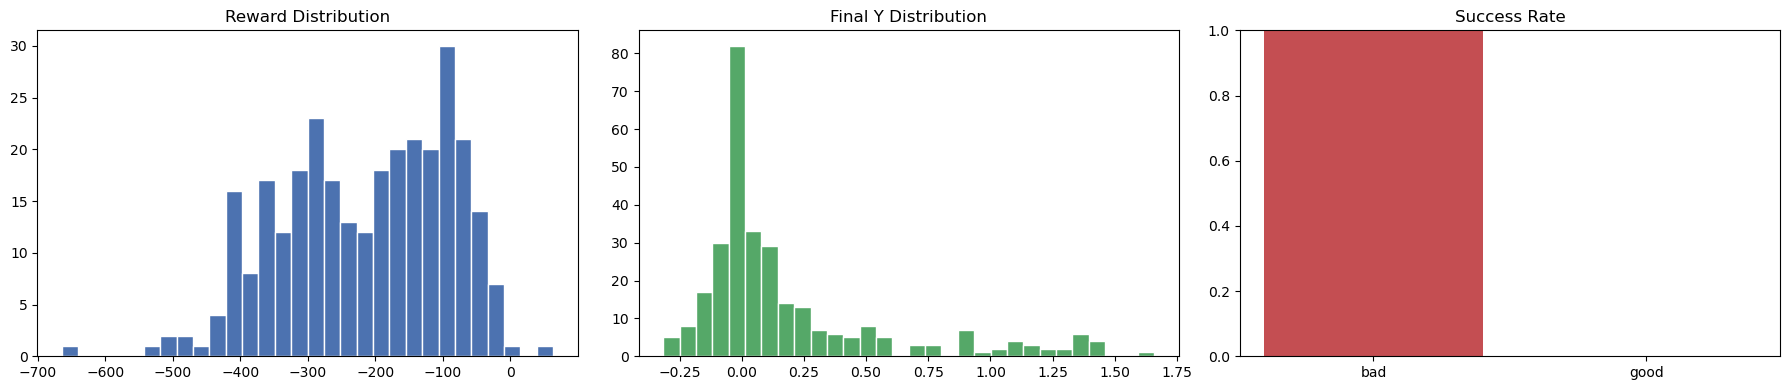

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(episode_returns, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")
axes[1].hist(final_y, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Final Y Distribution")
axes[2].bar(["bad", "good"], [1 - np.mean(successes), np.mean(successes)], color=["#c44e52", "#8172b3"])
axes[2].set_ylim(0, 1)
axes[2].set_title("Success Rate")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 1000 + rollout_idx)
    frames = []
    total_reward = 0.0
    actions = []
    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action = rollout_env.action_space.sample()
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        actions.append(float(np.mean(np.abs(action))))
        if terminated or truncated:
            break
    final_frame = rollout_env.render()
    if final_frame is not None:
        frames.extend([final_frame] * 20)
    rollout_summaries.append({"rollout_index": rollout_idx + 1, "seed": SEED + 1000 + rollout_idx, "total_reward": float(total_reward), "final_x": float(obs[0]), "final_y": float(obs[1]), "mean_abs_action": float(np.mean(actions)), "success": int(total_reward >= SUCCESS_THRESHOLD_RETURN)})
    if frames:
        imageio.mimsave(RESULTS_DIR / f"random_baseline_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,final_x,final_y,mean_abs_action,success
0,1,1042,-366.504284,0.872260,-0.225571,0.475385,0
1,2,1043,-48.772674,-0.062948,-0.006182,0.517306,0
2,3,1044,-195.823686,0.447563,0.024981,0.526346,0


In [7]:
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "random_baseline_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                 metric       value
         average_reward -216.097473
           success_rate    0.000000
 average_episode_length  112.030000
        average_final_x   -0.010865
        average_final_y    0.187643
average_mean_abs_action    0.501359
